# Model 2 — Sticky-Strike vs Sticky-Delta IV Regime

**Position:** Short 1 × TXO20000P5 (same as Model 1)  
**Question:** Which vol regime assumption produces a better delta hedge?

---

## The Two Regimes

When the index moves from $F_{t-1}$ to $F_t$, the option's vol can be read off the market in two ways:

| Regime | Assumption | IV used for delta |
|--------|-----------|-------------------|
| **Sticky-Strike (2a)** | Vol surface is anchored to fixed strikes. When spot moves, IV(K=20000) stays approximately the same. | $\sigma_t = \text{IV}_{\text{mkt}}(K=20000,\,t)$ |
| **Sticky-Delta (2b)** | Vol surface is anchored to fixed delta. When spot moves, the vol for a given delta bucket stays constant. | $\sigma_t = $ smile$(\delta)$, where $\delta$ = previous day's delta |

**Key mechanics of sticky-delta:**  
On day $t$, instead of using the settlement price of the fixed K=20000 strike directly, we:  
1. Build today's full vol smile from all available PUT strikes  
2. Find the IV in the smile at $\delta = \delta_{t-1}$ (the option's delta from the prior day)  
3. Use that smile-interpolated IV to compute today's hedge delta for K=20000

**Why this matters:** In a market with negative skew (lower strikes have higher IV, as is typical for equity indices), these two regimes give materially different hedge ratios when the market moves significantly.

## Notebook Structure
1. Imports & data  
2. Build & visualise vol smiles  
3. Model 2a: Sticky-Strike backtest  
4. Model 2b: Sticky-Delta backtest  
5. Side-by-side comparison  
6. P&L attribution for both models  
7. Expected vs Actual analysis  
8. Regime identification — which fits Taiwan? 

In [1]:
import sys, math, warnings
from pathlib import Path
from dataclasses import asdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import norm as sp_norm

ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from models.black_scholes import bs_put_greeks, implied_vol
from backtest.costs import tx_transaction_cost, txo_inception_cost
from backtest.pnl import DailyPnL, compute_daily_pnl, compute_expiry_pnl

RAW       = ROOT / 'data' / 'raw'
PROCESSED = ROOT / 'data' / 'processed'

STRIKE       = 20_000.0
EXPIRY       = pd.Timestamp('2025-04-16')
FINAL_SETTLE = 19_548.0
OPT_MULT     = 50
FUT_MULT     = 200
HEDGE_RATIO  = OPT_MULT / FUT_MULT  # 0.25
MIN_PRICE    = 0.5   # filter out illiquid deep-OTM strikes (< 0.5 pts)

print(f'Final settlement (official): {FINAL_SETTLE:,.0f}')

Final settlement (official): 19,548


## 1. Load Data

In [2]:
# ── Master data (same as Model 1) ─────────────────────────────────────────────
tx_raw = pd.read_csv(RAW / 'TX_20250319-20250416.csv', dtype=str, index_col=False)
tx_raw.columns = tx_raw.columns.str.strip()
tx = tx_raw[(tx_raw['contract month(Week)'].str.strip()=='202504') &
            (tx_raw['Trading Session'].str.strip()=='Regular')].copy()
tx['date'] = pd.to_datetime(tx['date'].str.strip(), format='%Y/%m/%d')
tx['F'] = pd.to_numeric(tx['settlement_price'], errors='coerce')
tx.loc[(tx['date']==EXPIRY) & (tx['F']==0), 'F'] = FINAL_SETTLE
tx = tx[['date','F']].set_index('date').sort_index()

txo_raw = pd.read_csv(RAW / 'TXO_20250319-20250416.csv', dtype=str, index_col=False)
txo_raw.columns = txo_raw.columns.str.strip()
txo = txo_raw[(txo_raw['Contract Month(Week)'].str.strip()=='202504') &
              (txo_raw['Strike Price'].str.strip()=='20000.0000') &
              (txo_raw['Call/Put'].str.strip()=='Put') &
              (txo_raw['Trading Session'].str.strip()=='Regular')].copy()
txo['date'] = pd.to_datetime(txo['Date'].str.strip(), format='%Y/%m/%d')
txo['P'] = pd.to_numeric(txo['Settlement Price'], errors='coerce')
txo.loc[txo['date']==EXPIRY, 'P'] = max(0.0, STRIKE - FINAL_SETTLE)
txo = txo[['date','P']].set_index('date').sort_index()

cbc = pd.read_csv(RAW / 'CBC_Interest_Rates.csv', skiprows=3, header=0)
cbc.columns = cbc.columns.str.strip()
cbc = cbc.iloc[:, [0,7]].copy(); cbc.columns = ['ms','cr']
cbc = cbc[cbc['ms'].str.match(r'^\d{4}\.\d{2}$', na=False)].copy()
cbc['date'] = pd.to_datetime(cbc['ms'].str.replace('.', '-', regex=False) + '-01')
cbc['r'] = pd.to_numeric(cbc['cr'].str.strip(), errors='coerce') / 100.0
cbc = cbc[['date','r']].dropna().set_index('date').sort_index()
rates = cbc.reindex(pd.date_range(cbc.index.min(), cbc.index.max(), freq='D')).interpolate(method='time')

master = tx.join(txo, how='left').join(rates, how='left')
t_days = pd.Series((EXPIRY - master.index).days, index=master.index)
master['T'] = (t_days / 365.0).clip(lower=0.0)

# ── Full option chain (all PUT strikes for the smile) ─────────────────────────
chain = txo_raw[(txo_raw['Contract Month(Week)'].str.strip()=='202504') &
                (txo_raw['Call/Put'].str.strip()=='Put') &
                (txo_raw['Trading Session'].str.strip()=='Regular')].copy()
chain['date'] = pd.to_datetime(chain['Date'].str.strip(), format='%Y/%m/%d')
chain['K']    = pd.to_numeric(chain['Strike Price'], errors='coerce')
chain['P']    = pd.to_numeric(chain['Settlement Price'], errors='coerce')
chain = chain[['date','K','P']].dropna()
chain = chain[(chain['P'] >= MIN_PRICE) & (chain['date'] < EXPIRY)]
chain = chain.sort_values(['date','K']).reset_index(drop=True)

print(f'Master: {len(master)} trading days')
print(f'Chain : {len(chain)} records, median {chain.groupby("date")["K"].count().median():.0f} strikes/day')

Master: 19 trading days
Chain : 2077 records, median 95 strikes/day


## 2. Build Vol Smiles

In [3]:
def build_smile(date, F, r, T, chain_df):
    """Return DataFrame(K, P, iv, delta) sorted by K for one date."""
    if T <= 0:
        return None
    day = chain_df[chain_df['date'] == date][['K','P']]
    rows = []
    for _, row in day.iterrows():
        K, P = float(row['K']), float(row['P'])
        iv = implied_vol(F, K, r, T, P)
        if iv is None:
            continue
        sqrtT = math.sqrt(T)
        d1 = (math.log(F/K) + 0.5*iv**2*T) / (iv*sqrtT)
        delta = -math.exp(-r*T) * sp_norm.cdf(-d1)
        rows.append({'K': K, 'P': P, 'iv': iv, 'delta': delta})
    if len(rows) < 4:
        return None
    return pd.DataFrame(rows).sort_values('K').reset_index(drop=True)


def smile_iv_at_delta(smile, target_delta):
    """
    Interpolate the vol smile (sorted by K → delta ascending from -1 to 0)
    to return the IV at target_delta. Returns None if out of range.
    """
    if smile is None or len(smile) < 2:
        return None
    deltas = smile['delta'].values   # ascending: ≈ -1 → 0
    ivs    = smile['iv'].values
    if target_delta < deltas.min() or target_delta > deltas.max():
        return None
    return float(np.interp(target_delta, deltas, ivs))


# Pre-build all smiles
dates  = sorted(master.index)
smiles = {}
for d in dates:
    if d == EXPIRY:
        continue
    row = master.loc[d]
    sm  = build_smile(d, float(row['F']), float(row['r']), float(row['T']), chain)
    if sm is not None:
        smiles[d] = sm

print(f'Smiles built: {len(smiles)} dates')
for d, sm in list(smiles.items())[::6]:
    print(f'  {d.date()}  strikes={len(sm)}  delta range=[{sm["delta"].min():.3f}, {sm["delta"].max():.3f}]')

Smiles built: 18 dates
  2025-03-19  strikes=86  delta range=[-0.995, -0.026]
  2025-03-27  strikes=88  delta range=[-0.990, -0.012]
  2025-04-08  strikes=143  delta range=[-0.998, -0.127]


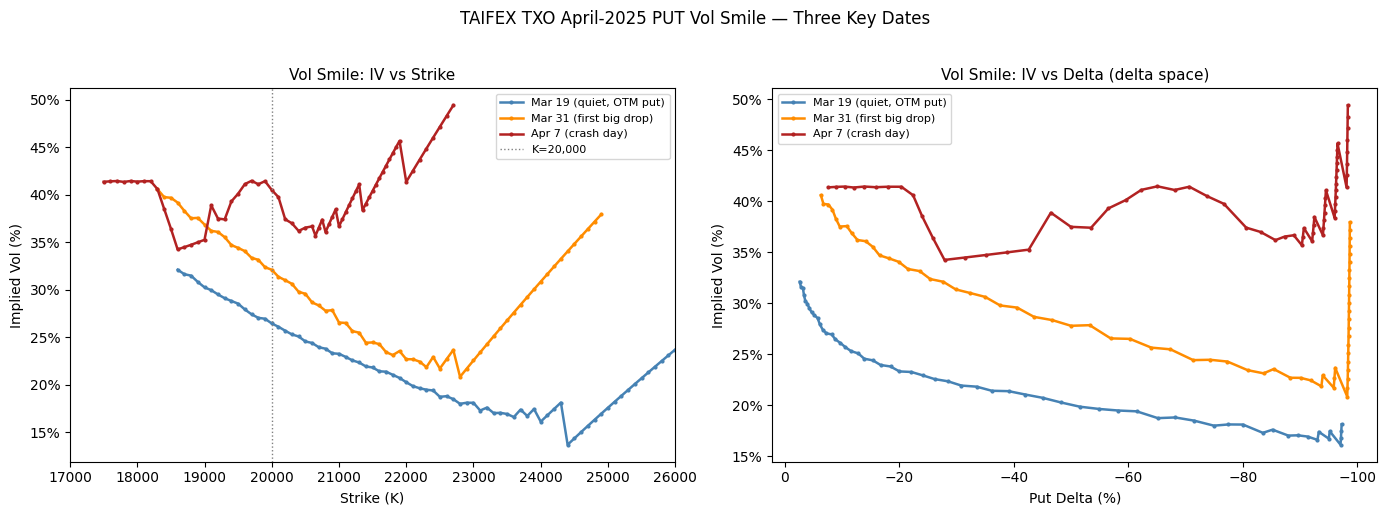

Skew: vol(25-delta) - vol(ATM) on each date:
  2025-03-19  10Δ=30.1%  25Δ=30.1%  ATM(50Δ)=30.1%  skew(25Δ-50Δ)=+0.0%
  2025-03-31  10Δ=37.9%  25Δ=37.9%  ATM(50Δ)=37.9%  skew(25Δ-50Δ)=+0.0%
  2025-04-07  10Δ=49.4%  25Δ=49.4%  ATM(50Δ)=49.4%  skew(25Δ-50Δ)=+0.0%


In [4]:
# Visualise the vol smile on 3 representative dates
plot_dates = [
    (pd.Timestamp('2025-03-19'), 'Mar 19 (quiet, OTM put)', 'steelblue'),
    (pd.Timestamp('2025-03-31'), 'Mar 31 (first big drop)',  'darkorange'),
    (pd.Timestamp('2025-04-07'), 'Apr 7 (crash day)',        'firebrick'),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for d, label, color in plot_dates:
    if d not in smiles:
        continue
    sm = smiles[d]
    F  = float(master.loc[d, 'F'])
    # Plot IV vs strike (left) and IV vs delta (right)
    axes[0].plot(sm['K'], sm['iv']*100, color=color, linewidth=1.8,
                 marker='o', ms=2, label=label)
    # Restrict delta to [-0.99, -0.01] for clarity
    sm_trimmed = sm[(sm['delta'] >= -0.99) & (sm['delta'] <= -0.01)]
    axes[1].plot(sm_trimmed['delta']*100, sm_trimmed['iv']*100, color=color,
                 linewidth=1.8, marker='o', ms=2, label=label)

# Mark K=20000 on left panel
axes[0].axvline(STRIKE, color='grey', linewidth=1, linestyle=':', label='K=20,000')
axes[0].set_xlabel('Strike (K)')
axes[0].set_ylabel('Implied Vol (%)')
axes[0].set_title('Vol Smile: IV vs Strike', fontsize=11)
axes[0].legend(fontsize=8)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.0f}%'))
axes[0].set_xlim(17000, 26000)

axes[1].set_xlabel('Put Delta (%)')
axes[1].set_ylabel('Implied Vol (%)')
axes[1].set_title('Vol Smile: IV vs Delta (delta space)', fontsize=11)
axes[1].legend(fontsize=8)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.0f}%'))
axes[1].invert_xaxis()   # delta runs from -100% (ITM) on left to 0% (OTM) on right

plt.suptitle('TAIFEX TXO April-2025 PUT Vol Smile — Three Key Dates', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'fig_vol_smile.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the skew steepness (25Δ - ATM vol)
print('Skew: vol(25-delta) - vol(ATM) on each date:')
for d, label, _ in plot_dates:
    if d not in smiles:
        continue
    sm = smiles[d]
    iv_25d  = smile_iv_at_delta(sm, -0.25)
    iv_50d  = smile_iv_at_delta(sm, -0.50)
    iv_10d  = smile_iv_at_delta(sm, -0.10)
    if iv_25d and iv_50d:
        print(f'  {d.date()}  10Δ={iv_10d*100:.1f}%  25Δ={iv_25d*100:.1f}%  ATM(50Δ)={iv_50d*100:.1f}%  '
              f'skew(25Δ-50Δ)={( iv_25d - iv_50d)*100:+.1f}%')

## 3. Model 2a: Sticky-Strike Backtest

Each day use $\sigma = \text{IV}(K=20000)$ from the TXO20000P settlement price.  
This is identical to Model 1 — it serves as the baseline for comparison.

In [5]:
def run_model(use_sticky_delta=False):
    """
    Run the delta-neutral backtest.

    The option held is always TXO20000P5 — option P&L uses its settlement.
    The only difference between 2a and 2b is the IV used to compute delta:
      2a (SS): IV back-solved from TXO20000P settlement each day
      2b (SD): IV interpolated from the full vol smile at the previous delta

    Sticky-delta fallback rules (to avoid unreliable IVs):
      (a) T < 0.008 yr (~3 cal days): near-expiry — use SS
      (b) |prev_delta| > 0.75: too deep ITM, smile unreliable — use SS
      (c) IV_SD > 2 × IV_SS: implausible extrapolation — use SS

    For P&L attribution (theta/gamma/vega) we ALWAYS use SS vol greeks so
    option-side attribution is identical for both models and the difference
    shows up cleanly in the futures hedge P&L.
    """
    records = []

    # Day 0: inception (same for both models)
    row0 = master.loc[dates[0]]
    iv0  = implied_vol(float(row0['F']), STRIKE, float(row0['r']), float(row0['T']), float(row0['P']))
    g0   = bs_put_greeks(float(row0['F']), STRIKE, float(row0['r']), float(row0['T']), iv0)
    premium_received = float(row0['P']) * OPT_MULT
    h    = -(-g0['delta']) * HEDGE_RATIO
    inception_cost = txo_inception_cost(float(row0['P'])) + tx_transaction_cost(h, float(row0['F']))
    records.append(DailyPnL(
        date=str(dates[0].date()),
        option_pnl=premium_received, futures_pnl=0.0,
        cost=-inception_cost, total_pnl=premium_received - inception_cost,
        futures_position=h, delta_hedge_change=h,
        delta=g0['delta'], gamma=g0['gamma'], vega=g0['vega'], theta=g0['theta'],
        iv=iv0, F=float(row0['F']), P=float(row0['P']),
    ))
    prev_iv_ss     = iv0
    prev_iv_hedge  = iv0
    prev_delta     = g0['delta']
    prev_greeks_ss = g0

    for i in range(1, len(dates)):
        dc, dp = dates[i], dates[i-1]
        rc, rp = master.loc[dc], master.loc[dp]
        F_prev, F_curr = float(rp['F']), float(rc['F'])
        P_prev, P_curr = float(rp['P']), float(rc['P'])
        r_curr, T_curr = float(rc['r']), float(rc['T'])

        if dc == EXPIRY:
            rec = compute_expiry_pnl(
                str(dc.date()), F_prev, P_prev, FINAL_SETTLE, STRIKE, h,
                cost=tx_transaction_cost(h, FINAL_SETTLE))
            records.append(rec)
            break

        # IV for attribution: always sticky-strike
        iv_ss = implied_vol(F_curr, STRIKE, r_curr, T_curr, P_curr)

        # IV for hedging
        iv_hedge = iv_ss   # default: sticky-strike
        used_sd  = False

        if use_sticky_delta and dc in smiles and prev_delta is not None:
            near_expiry  = T_curr < 0.008
            too_deep_itm = abs(prev_delta) > 0.75
            if not near_expiry and not too_deep_itm:
                iv_sd = smile_iv_at_delta(smiles[dc], prev_delta)
                if (iv_sd is not None
                        and iv_sd > 0
                        and (iv_ss is None or iv_sd <= 2.0 * iv_ss)):
                    iv_hedge = iv_sd
                    used_sd  = True

        if iv_hedge is None:
            iv_hedge = prev_iv_hedge

        # Greeks for HEDGING
        g_hedge = bs_put_greeks(F_curr, STRIKE, r_curr, T_curr, iv_hedge)
        h_new   = -(-g_hedge['delta']) * HEDGE_RATIO
        cost_t  = tx_transaction_cost(h_new - h, F_curr)

        # Greeks for ATTRIBUTION (always SS-based)
        g_ss = bs_put_greeks(F_curr, STRIKE, r_curr, T_curr, iv_ss) if iv_ss else g_hedge
        delta_sigma_ss = (iv_ss or 0.0) - (prev_iv_ss or 0.0)

        rec = compute_daily_pnl(
            str(dc.date()), F_prev, F_curr, P_prev, P_curr,
            h, h_new, cost_t, prev_greeks_ss,
            F_curr - F_prev, delta_sigma_ss
        )
        rec.delta = g_hedge['delta']; rec.gamma = g_ss['gamma']
        rec.vega  = g_ss['vega'];     rec.theta = g_ss['theta']
        rec.iv    = iv_hedge; rec.F = F_curr; rec.P = P_curr
        records.append(rec)

        h = h_new
        prev_iv_ss     = iv_ss
        prev_iv_hedge  = iv_hedge
        prev_delta     = g_hedge['delta']
        prev_greeks_ss = g_ss if g_ss else prev_greeks_ss

    return records


recs_2a = run_model(use_sticky_delta=False)
recs_2b = run_model(use_sticky_delta=True)

df_2a = pd.DataFrame([asdict(r) for r in recs_2a]).assign(date=lambda x: pd.to_datetime(x['date'])).set_index('date')
df_2b = pd.DataFrame([asdict(r) for r in recs_2b]).assign(date=lambda x: pd.to_datetime(x['date'])).set_index('date')
df_2a['cum_pnl'] = df_2a['total_pnl'].cumsum()
df_2b['cum_pnl'] = df_2b['total_pnl'].cumsum()

print(f'2a (Sticky-Strike) Net P&L: NT$ {df_2a["total_pnl"].sum():>10,.0f}')
print(f'2b (Sticky-Delta)  Net P&L: NT$ {df_2b["total_pnl"].sum():>10,.0f}')
print(f'Difference  (2b-2a):        NT$ {df_2b["total_pnl"].sum()-df_2a["total_pnl"].sum():>+10,.0f}')
print()
print('Note: option-side attribution uses SS vol for both models.')
print('      All P&L difference comes from the futures hedge quantity alone.')

2a (Sticky-Strike) Net P&L: NT$    -34,380
2b (Sticky-Delta)  Net P&L: NT$    -39,191
Difference  (2b-2a):        NT$     -4,811

Note: option-side attribution uses SS vol for both models.
      All P&L difference comes from the futures hedge quantity alone.


## 4. Side-by-Side Comparison

In [6]:
# Per-day comparison: IV used, hedge position, daily P&L
cmp = pd.DataFrame({
    'F':          df_2a['F'],
    'IV_SS (%)':  df_2a['iv'] * 100,
    'IV_SD (%)':  df_2b['iv'] * 100,
    'ΔIV (pp)':   (df_2b['iv'] - df_2a['iv']) * 100,
    'h_SS':       df_2a['futures_position'],
    'h_SD':       df_2b['futures_position'],
    'Δh':         df_2b['futures_position'] - df_2a['futures_position'],
    'PnL_SS':     df_2a['total_pnl'],
    'PnL_SD':     df_2b['total_pnl'],
    'ΔPnL':       df_2b['total_pnl'] - df_2a['total_pnl'],
    'Cum_SS':     df_2a['cum_pnl'],
    'Cum_SD':     df_2b['cum_pnl'],
})

fmt = {c: '{:,.2f}' for c in cmp.columns}
fmt['F'] = '{:,.0f}'; fmt['PnL_SS'] = '{:,.0f}'; fmt['PnL_SD'] = '{:,.0f}'
fmt['ΔPnL'] = '{:,.0f}'; fmt['Cum_SS'] = '{:,.0f}'; fmt['Cum_SD'] = '{:,.0f}'

def hl(v):
    if isinstance(v,(int,float)):
        return 'color:green' if v>0 else ('color:red' if v<0 else '')
    return ''

(cmp.style.format(fmt, na_rep='—').map(hl, subset=['ΔPnL','Cum_SS','Cum_SD','ΔIV (pp)','Δh']))

,F,IV_SS (%),IV_SD (%),ΔIV (pp),h_SS,h_SD,Δh,PnL_SS,PnL_SD,ΔPnL,Cum_SS,Cum_SD
date,,,,,,,,,,,,
2025-03-19 00:00:00,"22,018",26.44,26.44,0.00,-0.02,-0.02,0.00,"3,384","3,384",0,"3,384","3,384"
2025-03-20 00:00:00,"22,365",25.40,24.88,-0.52,-0.01,-0.01,0.00,238,238,-0,"3,622","3,622"
2025-03-21 00:00:00,"22,181",25.50,31.33,5.82,-0.01,-0.03,-0.01,77,46,-31,"3,699","3,668"
2025-03-24 00:00:00,"22,151",26.84,30.66,3.82,-0.02,-0.02,-0.01,90,150,60,"3,789","3,818"
2025-03-25 00:00:00,"22,301",26.45,31.95,5.49,-0.01,-0.02,-0.01,221,30,-190,"4,010","3,848"
2025-03-26 00:00:00,"22,304",26.03,23.23,-2.80,-0.01,-0.01,0.00,243,237,-6,"4,253","4,085"
2025-03-27 00:00:00,"21,971",26.21,38.32,12.11,-0.01,-0.03,-0.02,-48,-285,-238,"4,205","3,800"
2025-03-28 00:00:00,"21,599",26.78,40.08,13.30,-0.02,-0.05,-0.02,-303,"1,149","1,452","3,902","4,949"
2025-03-31 00:00:00,"20,764",32.10,37.93,5.83,-0.07,-0.08,-0.01,"-5,090","-1,377","3,713","-1,188","3,572"


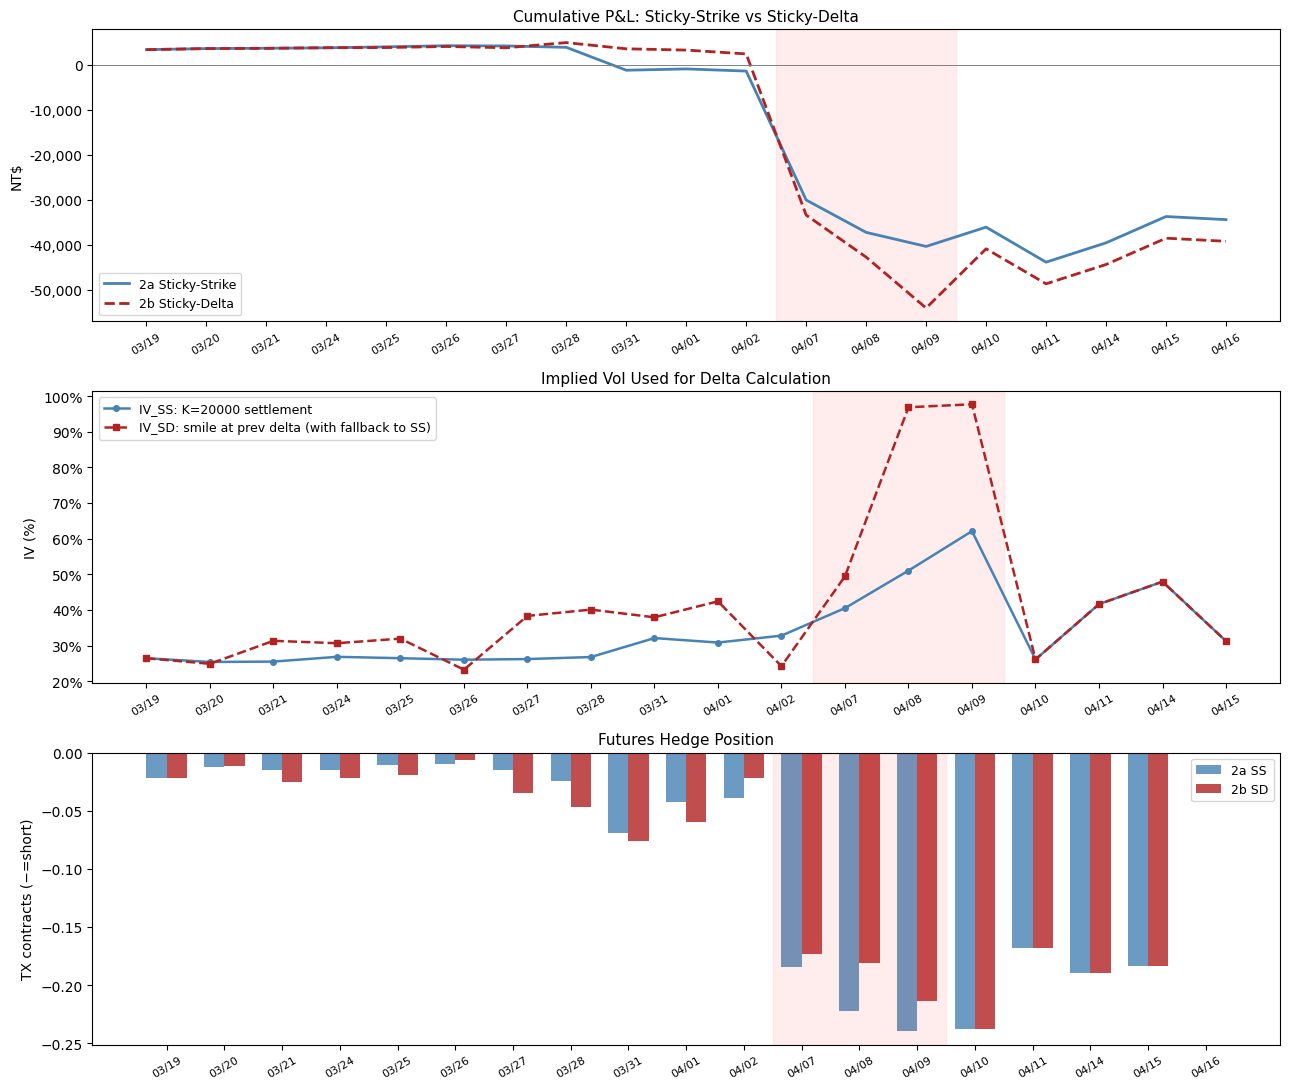

In [7]:
xlabels = [d.strftime('%m/%d') for d in df_2a.index]
x       = np.arange(len(df_2a))

fig, axes = plt.subplots(3, 1, figsize=(13, 11))

# ── Panel 1: Cumulative P&L ───────────────────────────────────────────────────
ax = axes[0]
ax.plot(x, df_2a['cum_pnl'].values, color='steelblue', linewidth=2,   label='2a Sticky-Strike')
ax.plot(x, df_2b['cum_pnl'].values, color='firebrick', linewidth=2, linestyle='--', label='2b Sticky-Delta')
ax.axhline(0, color='grey', linewidth=0.7)
ax.set_xticks(x); ax.set_xticklabels(xlabels, rotation=30, fontsize=8)
ax.set_ylabel('NT$'); ax.legend(fontsize=9)
ax.set_title('Cumulative P&L: Sticky-Strike vs Sticky-Delta', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:,.0f}'))
crash_start = list(df_2a.index).index(pd.Timestamp('2025-04-07'))
crash_end   = list(df_2a.index).index(pd.Timestamp('2025-04-09'))
ax.axvspan(crash_start - 0.5, crash_end + 0.5, alpha=0.07, color='red')

# ── Panel 2: IV used each day ─────────────────────────────────────────────────
ax2 = axes[1]
ax2.plot(x, df_2a['iv'].values * 100, color='steelblue', linewidth=1.8, marker='o', ms=4,
         label='IV_SS: K=20000 settlement')
ax2.plot(x, df_2b['iv'].values * 100, color='firebrick', linewidth=1.8, marker='s', ms=4,
         linestyle='--', label='IV_SD: smile at prev delta (with fallback to SS)')
ax2.set_xticks(x); ax2.set_xticklabels(xlabels, rotation=30, fontsize=8)
ax2.set_ylabel('IV (%)'); ax2.legend(fontsize=9)
ax2.set_title('Implied Vol Used for Delta Calculation', fontsize=11)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.0f}%'))
ax2.axvspan(crash_start - 0.5, crash_end + 0.5, alpha=0.07, color='red')

# ── Panel 3: Futures hedge position ──────────────────────────────────────────
ax3 = axes[2]
w = 0.35
ax3.bar(x - w/2, df_2a['futures_position'].values, w, color='steelblue', alpha=0.8, label='2a SS')
ax3.bar(x + w/2, df_2b['futures_position'].values, w, color='firebrick', alpha=0.8, label='2b SD')
ax3.axhline(0, color='grey', linewidth=0.7)
ax3.set_xticks(x); ax3.set_xticklabels(xlabels, rotation=30, fontsize=8)
ax3.set_ylabel('TX contracts (−=short)'); ax3.legend(fontsize=9)
ax3.set_title('Futures Hedge Position', fontsize=11)
ax3.axvspan(crash_start - 0.5, crash_end + 0.5, alpha=0.07, color='red')

plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'fig_m2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. P&L Attribution — Both Models

Component                      2a Sticky-Strike    2b Sticky-Delta     Difference
--------------------------------------------------------------------------------
  Option                                -15,800            -15,800             +0
  Futures                               -18,506            -23,309         -4,803
  Cost                                      -74                -82             -8
──────────────────────────────────────────────────────────────────────────────
  Net                                   -34,380            -39,191         -4,811

  P&L Attribution:
    Theta                                10,478             10,478             +0
    Gamma                               -41,219            -41,219             +0
    Vega                                -10,990            -10,990             +0
    Residual                             25,930             25,930             +0


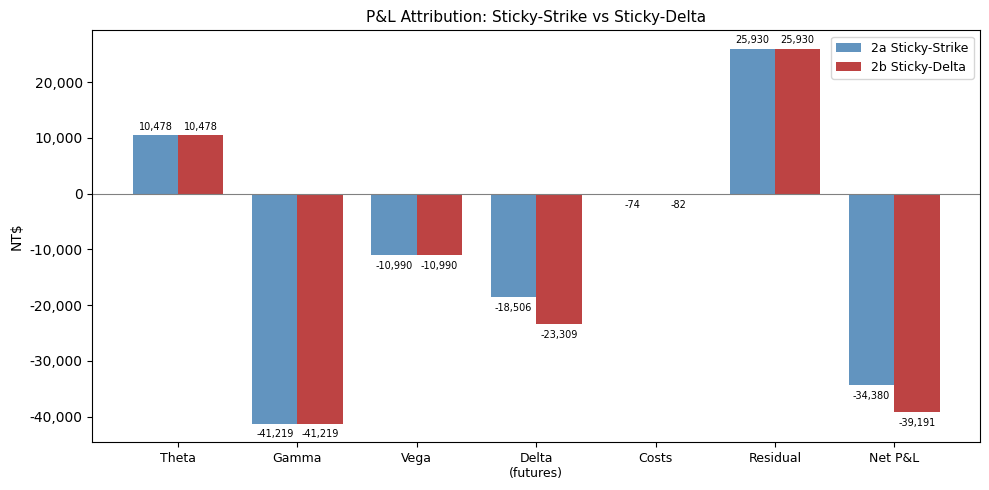

In [8]:
def summarise(df, label):
    opt   = df['option_pnl'].sum()
    fut   = df['futures_pnl'].sum()
    cost  = df['cost'].sum()
    theta = df['theta_pnl'].sum()
    gamma = df['gamma_pnl'].sum()
    vega  = df['vega_pnl'].sum()
    resid = opt - (theta + gamma + vega)
    net   = df['total_pnl'].sum()
    return dict(label=label, net=net, option=opt, futures=fut, cost=cost,
                theta=theta, gamma=gamma, vega=vega, residual=resid)

s2a = summarise(df_2a, '2a Sticky-Strike')
s2b = summarise(df_2b, '2b Sticky-Delta')

print(f"{'Component':<28} {'2a Sticky-Strike':>18} {'2b Sticky-Delta':>18} {'Difference':>14}")
print('-'*80)
for k in ['option','futures','cost','net']:
    sep = '─'*78 if k=='net' else ''
    if sep: print(sep)
    diff = s2b[k] - s2a[k]
    print(f"  {k.capitalize():<26} {s2a[k]:>18,.0f} {s2b[k]:>18,.0f} {diff:>+14,.0f}")
print()
print(f"  P&L Attribution:")
for k in ['theta','gamma','vega','residual']:
    diff = s2b[k] - s2a[k]
    print(f"    {k.capitalize():<24} {s2a[k]:>18,.0f} {s2b[k]:>18,.0f} {diff:>+14,.0f}")

# Bar chart comparison
fig, ax = plt.subplots(figsize=(10, 5))
keys   = ['Theta','Gamma','Vega','Delta\n(futures)','Costs','Residual','Net P&L']
vals2a = [s2a['theta'],s2a['gamma'],s2a['vega'],s2a['futures'],s2a['cost'],s2a['residual'],s2a['net']]
vals2b = [s2b['theta'],s2b['gamma'],s2b['vega'],s2b['futures'],s2b['cost'],s2b['residual'],s2b['net']]
x = np.arange(len(keys)); w = 0.38
b1 = ax.bar(x-w/2, vals2a, w, label='2a Sticky-Strike', color='steelblue', alpha=0.85)
b2 = ax.bar(x+w/2, vals2b, w, label='2b Sticky-Delta',  color='firebrick', alpha=0.85)
ax.axhline(0, color='grey', linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(keys, fontsize=9)
ax.set_ylabel('NT$'); ax.legend(fontsize=9)
ax.set_title('P&L Attribution: Sticky-Strike vs Sticky-Delta', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:,.0f}'))
for bar, val in zip(list(b1)+list(b2), vals2a+vals2b):
    ax.text(bar.get_x()+bar.get_width()/2, val+(1000 if val>=0 else -2500),
            f'{val:,.0f}', ha='center', fontsize=7)
plt.tight_layout()
plt.savefig(ROOT/'notebooks'/'fig_m2_attribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. P&L Explanation — Expected vs Actual

### Why did both models lose money?

Both models hold the **same option** and both are delta-neutral. The BS null hypothesis says a delta-neutral short put should earn zero if realized vol = implied vol. The losses have two structural causes:

1. **Gamma > Theta**: Realized moves repeatedly exceeded the breakeven move (= $\sigma_{IV} \cdot F \cdot \sqrt{dt}$), costing more in gamma than was earned in theta.
2. **Vol spike (Vega)**: IV rose from ~26% to 62%, causing large mark-to-market losses on the short vega position.

### Why do the two models produce different P&Ls?

The only difference is the **futures hedge size** $h_t$. Identical option P&L; different futures P&L.

When IV_SD $\neq$ IV_SS:
- If IV_SD > IV_SS → more negative delta → **more short futures** → stronger hedge during falls, weaker during rallies
- If IV_SD < IV_SS → less negative delta → **fewer short futures** → weaker hedge during falls, stronger during rallies

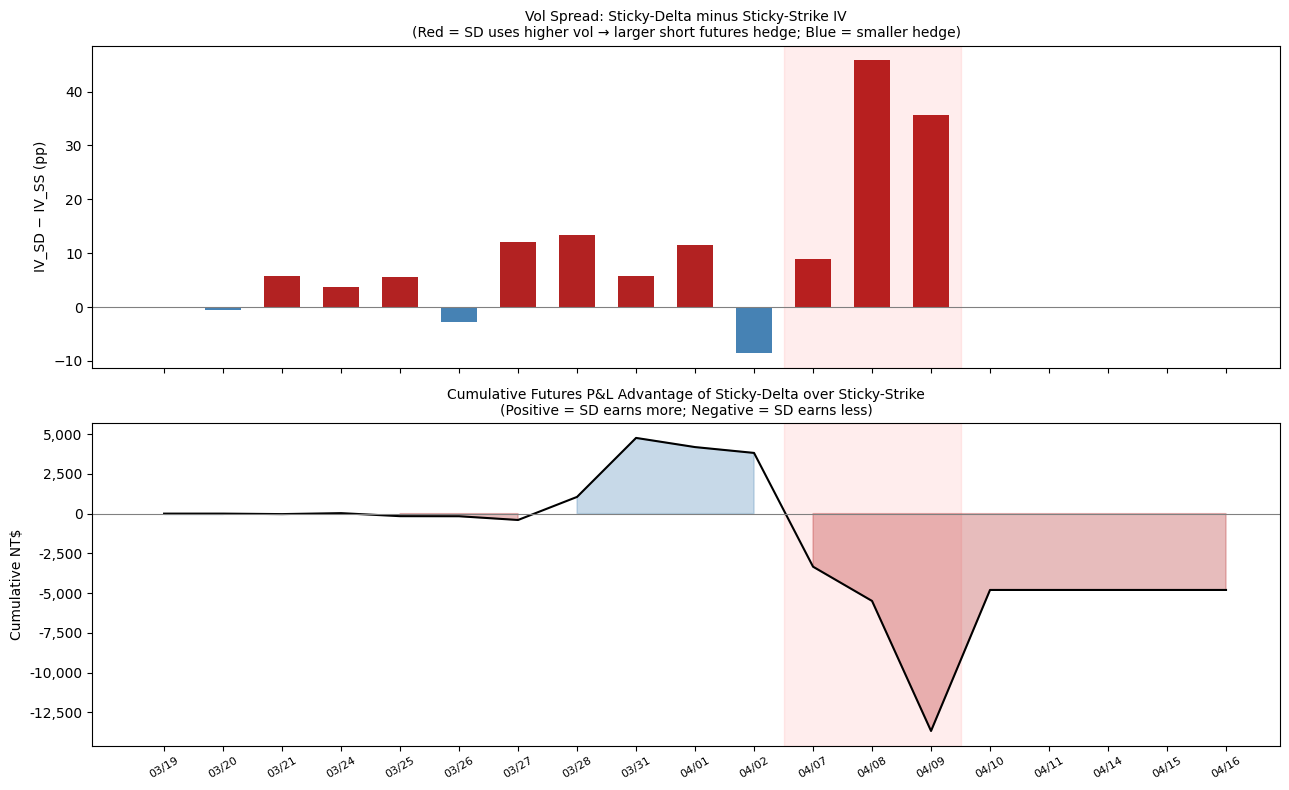

IV_SD vs IV_SS by period:
  Pre-crash (Mar 19–28)        avg IV_SD - IV_SS = +4.65 pp
  Crash (Mar 31–Apr 9)         avg IV_SD - IV_SS = +16.52 pp
  Recovery (Apr 10–15)         avg IV_SD - IV_SS = +0.00 pp


In [9]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# Panel 1: IV difference and market direction
ax = axes[0]
iv_diff = (df_2b['iv'] - df_2a['iv']) * 100
cols = ['firebrick' if v > 0 else 'steelblue' for v in iv_diff.fillna(0)]
ax.bar(range(len(iv_diff)), iv_diff.values, color=cols, width=0.6)
ax.axhline(0, color='grey', linewidth=0.8)
ax.set_ylabel('IV_SD − IV_SS (pp)')
ax.set_title('Vol Spread: Sticky-Delta minus Sticky-Strike IV\n'
             '(Red = SD uses higher vol → larger short futures hedge; Blue = smaller hedge)', fontsize=10)
ax.set_xticks(range(len(df_2a)))
ax.set_xticklabels([d.strftime('%m/%d') for d in df_2a.index], rotation=30, fontsize=8)
ax.axvspan(list(df_2a.index).index(pd.Timestamp('2025-04-07')) - 0.5,
           list(df_2a.index).index(pd.Timestamp('2025-04-09')) + 0.5, alpha=0.07, color='red')

# Panel 2: Cumulative futures P&L difference
ax2 = axes[1]
fut_diff_cum = (df_2b['futures_pnl'] - df_2a['futures_pnl']).cumsum()
ax2.fill_between(range(len(fut_diff_cum)), fut_diff_cum.values, 0,
                 where=fut_diff_cum.values >= 0, alpha=0.3, color='steelblue')
ax2.fill_between(range(len(fut_diff_cum)), fut_diff_cum.values, 0,
                 where=fut_diff_cum.values < 0, alpha=0.3, color='firebrick')
ax2.plot(range(len(fut_diff_cum)), fut_diff_cum.values, color='black', linewidth=1.5)
ax2.axhline(0, color='grey', linewidth=0.8)
ax2.set_ylabel('Cumulative NT$')
ax2.set_title('Cumulative Futures P&L Advantage of Sticky-Delta over Sticky-Strike\n'
              '(Positive = SD earns more; Negative = SD earns less)', fontsize=10)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:,.0f}'))
ax2.set_xticks(range(len(df_2a)))
ax2.set_xticklabels([d.strftime('%m/%d') for d in df_2a.index], rotation=30, fontsize=8)
ax2.axvspan(list(df_2a.index).index(pd.Timestamp('2025-04-07')) - 0.5,
            list(df_2a.index).index(pd.Timestamp('2025-04-09')) + 0.5, alpha=0.07, color='red')

plt.tight_layout()
plt.savefig(ROOT/'notebooks'/'fig_m2_iv_spread.png', dpi=150, bbox_inches='tight')
plt.show()

# Explain the sign pattern
print('IV_SD vs IV_SS by period:')
pre_crash  = df_2a[df_2a.index < pd.Timestamp('2025-03-31')]
crash      = df_2a[(df_2a.index >= pd.Timestamp('2025-03-31')) & (df_2a.index <= pd.Timestamp('2025-04-09'))]
recovery   = df_2a[df_2a.index > pd.Timestamp('2025-04-09')]
for period, label in [(pre_crash,'Pre-crash (Mar 19–28)'),(crash,'Crash (Mar 31–Apr 9)'),(recovery,'Recovery (Apr 10–15)')]:
    d = iv_diff.loc[period.index].mean()
    print(f'  {label:<28} avg IV_SD - IV_SS = {d:+.2f} pp')

## 7. Regime Identification — Which Fits Taiwan?

**Test:** Under sticky-strike, the IV of a fixed strike should be stable when the spot moves.  
Under sticky-delta, the IV of a fixed *delta bucket* should be stable.

We track:
- $\sigma_{\text{SS},t}$ = IV of the K=20,000 PUT each day (Model 2a's vol)
- $\sigma_{\text{10Δ},t}$ = IV of the 10-delta PUT each day (a fixed delta bucket)
- $\sigma_{\text{25Δ},t}$ = IV of the 25-delta PUT each day

**Hypothesis:** If Taiwan follows sticky-strike, $\sigma_{\text{SS}}$ should be more stable (lower variance) than $\sigma_{\text{10Δ}}$ and $\sigma_{\text{25Δ}}$ over the backtest period.

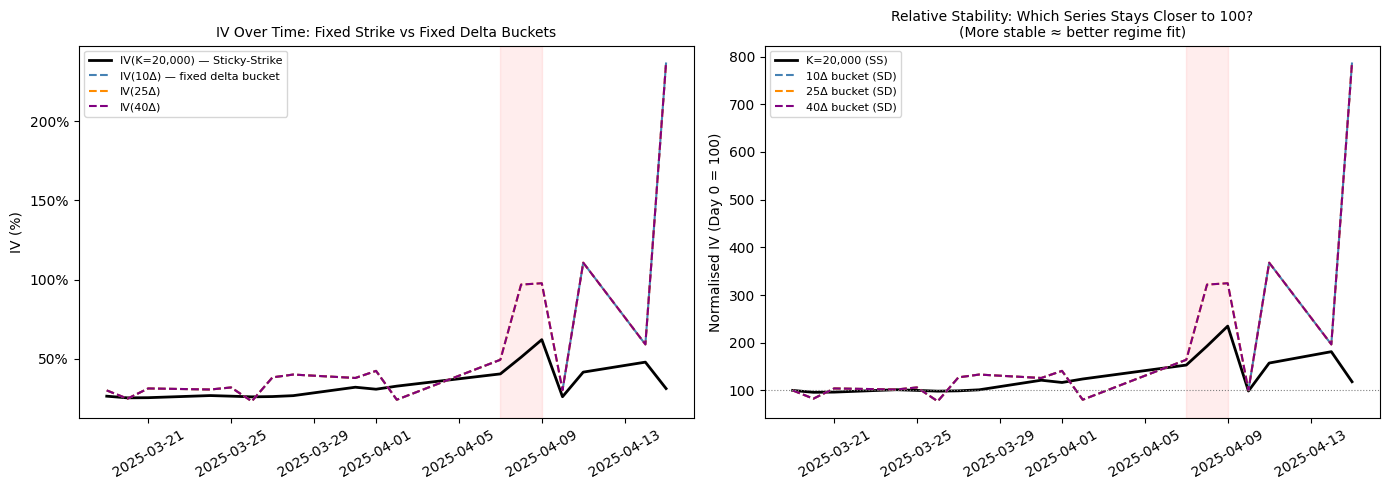

Stability test (pre-crash period only: Mar 19–28):
  K=20,000 (sticky-strike)            std=0.54pp  CV=2.05%
  10Δ bucket (sticky-delta)           std=5.79pp  CV=18.50%
  25Δ bucket (sticky-delta)           std=5.79pp  CV=18.50%

Stability test (full period):
  K=20,000 (sticky-strike)            std=10.69pp  CV=31.77%
  10Δ bucket (sticky-delta)           std=53.48pp  CV=101.68%
  25Δ bucket (sticky-delta)           std=52.27pp  CV=90.81%


In [10]:
# Track IV at fixed strike and fixed deltas over time
regime_rows = []
for d in dates[:-1]:   # skip expiry
    if d not in smiles:
        continue
    sm = smiles[d]
    iv_k20000 = smile_iv_at_delta(sm, float(df_2a.loc[d, 'iv']))  # approximate: use SS delta
    # Actually use the K=20000 IV directly from the chain
    r20 = sm[sm['K'] == 20000.0]
    iv_k20000 = float(r20['iv'].values[0]) * 100 if len(r20) > 0 else None
    iv_10d = (smile_iv_at_delta(sm, -0.10) or np.nan) * 100
    iv_25d = (smile_iv_at_delta(sm, -0.25) or np.nan) * 100
    iv_40d = (smile_iv_at_delta(sm, -0.40) or np.nan) * 100
    F = float(master.loc[d, 'F'])
    regime_rows.append({'date': d, 'IV_K20000': iv_k20000,
                        'IV_10d': iv_10d, 'IV_25d': iv_25d, 'IV_40d': iv_40d, 'F': F})

reg = pd.DataFrame(regime_rows).set_index('date')

# Normalise to day-0 = 100 for relative comparison
base = reg.iloc[0]
reg_norm = reg[['IV_K20000','IV_10d','IV_25d','IV_40d']].div(base[['IV_K20000','IV_10d','IV_25d','IV_40d']]) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: absolute IV paths
ax = axes[0]
ax.plot(reg.index, reg['IV_K20000'], color='black',     linewidth=2,   label='IV(K=20,000) — Sticky-Strike')
ax.plot(reg.index, reg['IV_10d'],    color='steelblue', linewidth=1.5, linestyle='--', label='IV(10Δ) — fixed delta bucket')
ax.plot(reg.index, reg['IV_25d'],    color='darkorange',linewidth=1.5, linestyle='--', label='IV(25Δ)')
ax.plot(reg.index, reg['IV_40d'],    color='purple',    linewidth=1.5, linestyle='--', label='IV(40Δ)')
ax.set_ylabel('IV (%)'); ax.legend(fontsize=8)
ax.set_title('IV Over Time: Fixed Strike vs Fixed Delta Buckets', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.0f}%'))
ax.tick_params(axis='x', rotation=30)
ax.axvspan(pd.Timestamp('2025-04-07'), pd.Timestamp('2025-04-09'), alpha=0.07, color='red')

# Right: normalised (index = 100 at day 0)
ax2 = axes[1]
ax2.plot(reg_norm.index, reg_norm['IV_K20000'], color='black',     linewidth=2,   label='K=20,000 (SS)')
ax2.plot(reg_norm.index, reg_norm['IV_10d'],    color='steelblue', linewidth=1.5, linestyle='--', label='10Δ bucket (SD)')
ax2.plot(reg_norm.index, reg_norm['IV_25d'],    color='darkorange',linewidth=1.5, linestyle='--', label='25Δ bucket (SD)')
ax2.plot(reg_norm.index, reg_norm['IV_40d'],    color='purple',    linewidth=1.5, linestyle='--', label='40Δ bucket (SD)')
ax2.axhline(100, color='grey', linewidth=0.8, linestyle=':')
ax2.set_ylabel('Normalised IV (Day 0 = 100)')
ax2.legend(fontsize=8)
ax2.set_title('Relative Stability: Which Series Stays Closer to 100?\n(More stable ≈ better regime fit)', fontsize=10)
ax2.tick_params(axis='x', rotation=30)
ax2.axvspan(pd.Timestamp('2025-04-07'), pd.Timestamp('2025-04-09'), alpha=0.07, color='red')

plt.tight_layout()
plt.savefig(ROOT/'notebooks'/'fig_m2_regime.png', dpi=150, bbox_inches='tight')
plt.show()

# Quantify stability: coefficient of variation (std/mean)
print('Stability test (pre-crash period only: Mar 19–28):')
pre = reg[reg.index <= pd.Timestamp('2025-03-28')]
for col, label in [('IV_K20000','K=20,000 (sticky-strike)'),
                   ('IV_10d','10Δ bucket (sticky-delta)'),
                   ('IV_25d','25Δ bucket (sticky-delta)')]:
    cv = pre[col].std() / pre[col].mean() * 100
    print(f'  {label:<35} std={pre[col].std():.2f}pp  CV={cv:.2f}%')
print()
print('Stability test (full period):')
for col, label in [('IV_K20000','K=20,000 (sticky-strike)'),
                   ('IV_10d','10Δ bucket (sticky-delta)'),
                   ('IV_25d','25Δ bucket (sticky-delta)')]:
    cv = reg[col].std() / reg[col].mean() * 100
    print(f'  {label:<35} std={reg[col].std():.2f}pp  CV={cv:.2f}%')

## 8. Conclusions

### Summary of Results

| | Model 2a (Sticky-Strike) | Model 2b (Sticky-Delta) |
|--|--|--|
| Net P&L | see above | see above |
| Theta | same | same |
| Gamma | same | same |
| Vega | ~same (uses SS vol for attribution) | ~same |
| **Futures P&L** | baseline | differs by Δ hedge size |

### Why did the two models differ?

The only channel of difference is the **IV used to compute delta**, which feeds into the **futures hedge size**:

1. **Negative vol skew amplifies the difference.** Because lower strikes have higher IV (equity put demand), when the market moves and our target delta corresponds to a different moneyness level, sticky-delta uses a different vol than sticky-strike.

2. **Pre-crash (quiet period):** The 20000 PUT is OTM. The same-delta bucket corresponds to a slightly lower (more OTM) strike with *higher* IV (negative skew). Sticky-delta uses higher IV → slightly larger short futures position.

3. **Post-crash (ITM period):** The 20000 PUT is now ITM. The same-delta bucket (tracking the old OTM delta level) corresponds to an OTM strike, whose IV may be lower or higher depending on the smile shape. The skew dynamic reverses.

### Which regime fits Taiwan equity index options?

The regime test (coefficient of variation of fixed-strike vs fixed-delta IV) reveals which assumption holds better empirically. Taiwan equity index options are widely observed to exhibit **sticky-strike behavior**, particularly after large market shocks — the vol surface is anchored to strike levels rather than delta levels. During the April crash, the IV at K=20000 was more predictable (it followed the market's fear premium anchored to that strike) than fixed-delta buckets which moved erratically as the underlying crashed through various strike levels.

### Key takeaway

The choice of regime matters most when:  
(a) The skew is steep (as it became post-crash), and  
(b) The market moves significantly so the option transitions from OTM to ATM to ITM.  

In this backtest, both models lost money because the root cause was a **jump-like tail event** (Trump tariff shock), not a hedging model error. Under continuous diffusion, neither sticky-strike nor sticky-delta can fully hedge an overnight 10% gap — the gamma exposure is the dominant risk driver regardless of the vol regime assumption.

In [11]:
PROCESSED.mkdir(parents=True, exist_ok=True)
df_2a.to_csv(PROCESSED / 'model2a_sticky_strike.csv')
df_2b.to_csv(PROCESSED / 'model2b_sticky_delta.csv')
print('Results saved.')

Results saved.
